In [ ]:
# ============================================================
# CELL 1 — Setup + unzip
# ============================================================
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile, glob, os
import matplotlib.pyplot as plt
import seaborn as sns

zip_files = glob.glob('/content/*.zip')
with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall('/content/dataset')

CLASSES      = ['notumor', 'meningioma', 'glioma', 'pituitary']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
DATASET_PATH = '/content/dataset'

print("GPU:", tf.config.list_physical_devices('GPU'))
print("Setup done")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup done


In [ ]:
# ============================================================
# CELL 2 — File paths + 10% labeled split
# ============================================================
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Training',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Testing',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

labeled_idx, unlabeled_idx = train_test_split(
    np.arange(len(train_gen.filepaths)),
    test_size=0.90,   # 10% labeled = 560 images
    stratify=train_gen.labels,
    random_state=42
)

labeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in labeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in labeled_idx]
})
unlabeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in unlabeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in unlabeled_idx]
})
test_df = pd.DataFrame({
    'filename': test_gen.filepaths,
    'class':    [CLASSES[l] for l in test_gen.labels]
})

print(f" Labeled:   {len(labeled_df)}")
print(f" Unlabeled: {len(unlabeled_df)}")
print(f"Test:      {len(test_df)}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Labeled:   560
 Unlabeled: 5040
Test:      1600


In [ ]:
# ============================================================
# CELL 3 — tf.data pipeline with correct ResNet50 preprocessing
# ============================================================
def build_dataset(dataframe, labeled=True, augment=False, batch_size=32):
    filepaths = dataframe['filename'].values

    def load_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = preprocess_input(img)  # correct ResNet50 preprocessing
        return img

    def augment_fn(img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return img

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if labeled:
        labels = [CLASSES.index(c) for c in dataframe['class'].values]
        label_ds = tf.data.Dataset.from_tensor_slices(
            tf.keras.utils.to_categorical(labels, 4)
        )
        ds = tf.data.Dataset.zip((ds, label_ds))
        ds = ds.shuffle(500)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

labeled_ds   = build_dataset(labeled_df,   labeled=True,  augment=True)
unlabeled_ds = build_dataset(unlabeled_df,  labeled=False, augment=False)
test_ds      = build_dataset(test_df,       labeled=True,  augment=False)

print(" All datasets ready")

 All datasets ready


In [ ]:
# ============================================================
# CELL 4 — ResNet50 model
# ============================================================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = base_model.input
x       = layers.GlobalAveragePooling2D()(base_model.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" ResNet50 ready")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
 ResNet50 ready


In [ ]:
# ============================================================
# CELL 5 — Phase 1 training
# ============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/best_model.keras', save_best_only=True, verbose=1
    )
]

# Stage 1 — head only
print(" Stage 1: Training head only...")
model.fit(
    labeled_ds, epochs=10,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

# Stage 2 — unfreeze last 30 layers
print("\n Stage 2: Fine tuning last 30 layers...")
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    labeled_ds, epochs=20,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n Phase 1 Accuracy: {acc*100:.2f}%")

 Stage 1: Training head only...
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.5368 - loss: 1.3377
Epoch 1: val_loss improved from None to 1.31354, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7054 - loss: 0.9311 - val_accuracy: 0.6400 - val_loss: 1.3135 - learning_rate: 0.0010
Epoch 2/10
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8441 - loss: 0.4411
Epoch 2: val_loss improved from 1.31354 to 1.03503, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 446ms/step - accuracy: 0.8607 - loss: 0.4100 - val_accuracy: 0.6944 - val_loss: 1.0350 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9221 - loss: 0.2695
Epoch 3: val_loss did not improve from 1.03503
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step - accuracy: 0.9143 - loss: 0.2861 - 

In [6]:
# ============================================================
# CELL 6 — Pseudo-labeling
# ============================================================
print(" Generating pseudo-labels...")

unlabeled_ds_ordered = build_dataset(unlabeled_df, labeled=False, augment=False)
predictions   = model.predict(unlabeled_ds_ordered, verbose=1)
confidence    = np.max(predictions, axis=1)
pseudo_labels = np.argmax(predictions, axis=1)

print(f" Confidence >0.95: {np.sum(confidence > 0.95)}")
print(f" Confidence >0.90: {np.sum(confidence > 0.90)}")
print(f" Confidence >0.85: {np.sum(confidence > 0.85)}")
print(f" Confidence >0.80: {np.sum(confidence > 0.80)}")

# Start with 0.85 — adjust based on output
THRESHOLD = 0.85
mask = confidence > THRESHOLD

pseudo_df = pd.DataFrame({
    'filename': unlabeled_df['filename'].values[mask],
    'class':    [CLASSES[i] for i in pseudo_labels[mask]]
})

combined_df = pd.concat([labeled_df, pseudo_df], ignore_index=True)
print(f"\n Pseudo-labeled: {len(pseudo_df)}")
print(f"Combined total: {len(combined_df)}")
print(combined_df['class'].value_counts())

 Generating pseudo-labels...
158/158 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step
 Confidence >0.95: 3462
 Confidence >0.90: 3840
 Confidence >0.85: 4089
 Confidence >0.80: 4263

 Pseudo-labeled: 4089
Combined total: 4649
class
meningioma    1452
notumor       1178
pituitary     1062
glioma         957
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 7 — Retrain on combined data
# ============================================================
combined_ds = build_dataset(combined_df, labeled=True, augment=True)

print(" Phase 2: Retraining on labeled + pseudo-labeled...")
model.fit(
    combined_ds, epochs=20,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n Phase 2 Accuracy: {acc*100:.2f}%")

 Phase 2: Retraining on labeled + pseudo-labeled...
Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9405 - loss: 0.2131
Epoch 1: val_loss did not improve from 0.92462
146/146 ━━━━━━━━━━━━━━━━━━━━ 37s 240ms/step - accuracy: 0.9378 - loss: 0.2115 - val_accuracy: 0.7844 - val_loss: 1.1983 - learning_rate: 3.0000e-05
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9400 - loss: 0.2092
Epoch 2: val_loss did not improve from 0.92462
146/146 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.9471 - loss: 0.1726 - val_accuracy: 0.7912 - val_loss: 1.1924 - learning_rate: 3.0000e-05
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9533 - loss: 0.1540
Epoch 3: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.

Epoch 3: val_loss did not improve from 0.92462
146/146 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 0.9602 - loss: 0.1274 - val_accuracy: 0.7856 - val_loss: 1.3423 - learning_rate: 3.0000e-05
Epoch 4/20
146/146 ━━━

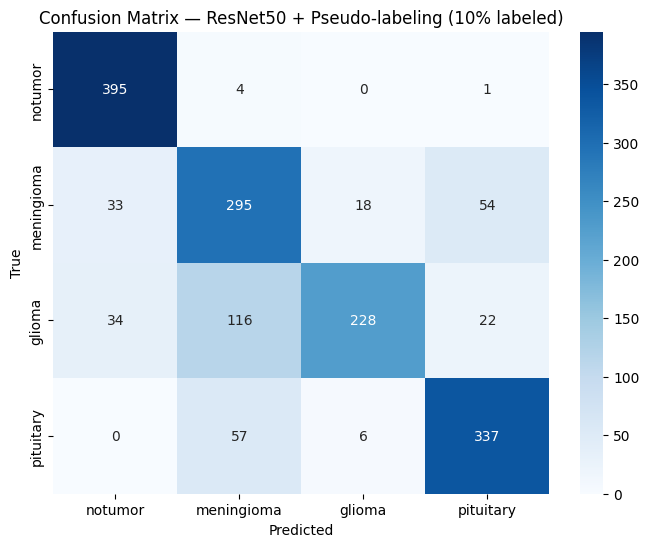

              precision    recall  f1-score   support

     notumor       0.85      0.99      0.92       400
  meningioma       0.62      0.74      0.68       400
      glioma       0.90      0.57      0.70       400
   pituitary       0.81      0.84      0.83       400

    accuracy                           0.78      1600
   macro avg       0.80      0.78      0.78      1600
weighted avg       0.80      0.78      0.78      1600



In [8]:
# ============================================================
# CELL 8 — Final evaluation
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_true = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — ResNet50 + Pseudo-labeling (10% labeled)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASSES))

In [9]:
# Smart iterative pseudo-labeling
# Round 3 — lower threshold gradually as model gets more confident

for round_num, threshold in enumerate([0.88, 0.85, 0.80], start=3):
    print(f"\n Round {round_num} — threshold: {threshold}")

    # Predict on unlabeled
    unlabeled_ds_ordered = build_dataset(unlabeled_df, labeled=False, augment=False)
    preds      = model.predict(unlabeled_ds_ordered, verbose=0)
    confidence = np.max(preds, axis=1)
    plabels    = np.argmax(preds, axis=1)

    print(f"   Passing threshold: {np.sum(confidence > threshold)}")

    # Build combined dataset
    mask = confidence > threshold
    pseudo = pd.DataFrame({
        'filename': unlabeled_df['filename'].values[mask],
        'class':    [CLASSES[i] for i in plabels[mask]]
    })
    combined = pd.concat([labeled_df, pseudo], ignore_index=True)
    print(f"   Combined size: {len(combined)}")
    print(combined['class'].value_counts().to_dict())

    # Retrain
    combined_ds = build_dataset(combined, labeled=True, augment=True)
    model.fit(
        combined_ds, epochs=10,
        validation_data=test_ds,
        callbacks=callbacks, verbose=0
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"    Accuracy: {acc*100:.2f}%")


 Round 3 — threshold: 0.88
   Passing threshold: 4346
   Combined size: 4906
{'meningioma': 1443, 'notumor': 1263, 'pituitary': 1200, 'glioma': 1000}

Epoch 1: val_loss did not improve from 0.92462

Epoch 2: val_loss did not improve from 0.92462

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.

Epoch 3: val_loss did not improve from 0.92462

Epoch 4: val_loss did not improve from 0.92462

Epoch 5: val_loss did not improve from 0.92462
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
    Accuracy: 79.25%

 Round 4 — threshold: 0.85
   Passing threshold: 4556
   Combined size: 5116
{'meningioma': 1455, 'pituitary': 1321, 'notumor': 1280, 'glioma': 1060}

Epoch 1: val_loss did not improve from 0.92462

Epoch 2: val_loss did not improve from 0.92462

Epoch 3: ReduceLROnPlateau reducing learning rate to 8.099999604382901e-07.

Epoch 3: val_loss did not improve from 0.92462

Epoch 4: val_loss did not improve from 0.92462

Epoch 

FixMatch Implementation

In [10]:
# ============================================================
# CELL 1 — Setup + unzip (same as before)
# ============================================================
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile, glob, os
import matplotlib.pyplot as plt
import seaborn as sns

zip_files = glob.glob('/content/*.zip')
with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall('/content/dataset')

CLASSES      = ['notumor', 'meningioma', 'glioma', 'pituitary']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
DATASET_PATH = '/content/dataset'

print("GPU:", tf.config.list_physical_devices('GPU'))
print(" Setup done")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 Setup done


In [11]:
# ============================================================
# CELL 2 — File paths + 10% labeled split
# ============================================================
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Training',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Testing',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

labeled_idx, unlabeled_idx = train_test_split(
    np.arange(len(train_gen.filepaths)),
    test_size=0.90,
    stratify=train_gen.labels,
    random_state=42
)

labeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in labeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in labeled_idx]
})
unlabeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in unlabeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in unlabeled_idx]
})
test_df = pd.DataFrame({
    'filename': test_gen.filepaths,
    'class':    [CLASSES[l] for l in test_gen.labels]
})

print(f" Labeled:   {len(labeled_df)}")
print(f" Unlabeled: {len(unlabeled_df)}")
print(f" Test:      {len(test_df)}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Labeled:   560
 Unlabeled: 5040
 Test:      1600


In [12]:
# ============================================================
# CELL 3 — Weak + Strong augmentation datasets
# ============================================================
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = preprocess_input(img)
    return img

def weak_augment(img):
    img = tf.image.random_flip_left_right(img)
    return img

def strong_augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.3)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img

def build_labeled_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((ds, label_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_unlabeled_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values

    ds = tf.data.Dataset.from_tensor_slices(filepaths)

    # Weak augmented version
    weak_ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    weak_ds = weak_ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Strong augmented version of same images
    strong_ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    strong_ds = strong_ds.map(strong_augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Zip weak + strong together
    ds = tf.data.Dataset.zip((weak_ds, strong_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_test_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((ds, label_ds))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

labeled_ds   = build_labeled_ds(labeled_df)
unlabeled_ds = build_unlabeled_ds(unlabeled_df)
test_ds      = build_test_ds(test_df)

print(" All datasets ready")

 All datasets ready


In [13]:
# ============================================================
# CELL 4 — ResNet50 model
# ============================================================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze last 30 layers from start
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

inputs  = base_model.input
x       = layers.GlobalAveragePooling2D()(base_model.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
optimizer = tf.keras.optimizers.Adam(1e-4)

print(" ResNet50 ready")

 ResNet50 ready


In [14]:
# ============================================================
# CELL 5 — FixMatch custom training loop
# ============================================================
CONFIDENCE_THRESHOLD = 0.95
LAMBDA_U = 1.0       # weight of unlabeled loss
EPOCHS   = 30
STEPS_PER_EPOCH = len(labeled_ds)

# Loss functions
supervised_loss_fn   = tf.keras.losses.CategoricalCrossentropy()
unsupervised_loss_fn = tf.keras.losses.CategoricalCrossentropy()

@tf.function
def train_step(labeled_batch, unlabeled_batch):
    labeled_imgs, labels     = labeled_batch
    weak_imgs,    strong_imgs = unlabeled_batch

    with tf.GradientTape() as tape:
        # Supervised loss on labeled data
        labeled_preds = model(labeled_imgs, training=True)
        loss_s = supervised_loss_fn(labels, labeled_preds)

        # Pseudo labels from weak augmented unlabeled
        weak_preds   = model(weak_imgs, training=False)
        pseudo_conf  = tf.reduce_max(weak_preds, axis=1)
        pseudo_labels = tf.one_hot(tf.argmax(weak_preds, axis=1), 4)

        # Mask — only keep high confidence predictions
        mask = tf.cast(pseudo_conf >= CONFIDENCE_THRESHOLD, tf.float32)

        # Consistency loss on strongly augmented unlabeled
        strong_preds = model(strong_imgs, training=True)
        loss_u = unsupervised_loss_fn(pseudo_labels, strong_preds)
        loss_u = tf.reduce_mean(loss_u * mask)

        # Total loss
        total_loss = loss_s + LAMBDA_U * loss_u

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss_s, loss_u, tf.reduce_mean(mask)

# Evaluation function
def evaluate(dataset):
    correct, total = 0, 0
    for imgs, labels in dataset:
        preds = model(imgs, training=False)
        correct += tf.reduce_sum(
            tf.cast(tf.equal(tf.argmax(preds, 1), tf.argmax(labels, 1)), tf.float32)
        ).numpy()
        total += len(imgs)
    return correct / total

# Training loop
best_acc = 0
unlabeled_iter = iter(unlabeled_ds.repeat())

print(" FixMatch Training...")
print(f"{'Epoch':>6} {'S_Loss':>8} {'U_Loss':>8} {'Mask%':>7} {'Val_Acc':>8}")
print("-" * 45)

for epoch in range(EPOCHS):
    s_losses, u_losses, masks = [], [], []

    for labeled_batch in labeled_ds:
        unlabeled_batch = next(unlabeled_iter)
        ls, lu, mask = train_step(labeled_batch, unlabeled_batch)
        s_losses.append(ls.numpy())
        u_losses.append(lu.numpy())
        masks.append(mask.numpy())

    val_acc = evaluate(test_ds)

    print(f"{epoch+1:>6} {np.mean(s_losses):>8.4f} {np.mean(u_losses):>8.4f} "
          f"{np.mean(masks)*100:>6.1f}% {val_acc*100:>7.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        model.save('/content/best_fixmatch.keras')

print(f"\n Best FixMatch Accuracy: {best_acc*100:.2f}%")

 FixMatch Training...
 Epoch   S_Loss   U_Loss   Mask%  Val_Acc
---------------------------------------------
     1   0.9193   0.0777    6.6%   64.12%
     2   0.2239   0.2702   34.0%   69.62%
     3   0.1202   0.2343   47.2%   80.19%
     4   0.0473   0.1692   64.4%   80.69%
     5   0.0288   0.2032   74.8%   79.12%
     6   0.0296   0.2743   76.2%   75.94%
     7   0.0481   0.2555   78.6%   77.44%
     8   0.0354   0.2083   80.4%   78.25%
     9   0.0506   0.2865   85.9%   79.56%
    10   0.0304   0.2344   80.2%   80.56%
    11   0.0168   0.1694   88.9%   81.06%
    12   0.0137   0.1847   86.5%   82.12%
    13   0.0346   0.2315   85.4%   81.56%
    14   0.0140   0.2040   86.5%   79.00%
    15   0.0249   0.1921   89.1%   78.50%
    16   0.0109   0.2116   86.8%   82.81%
    17   0.0208   0.2191   84.4%   81.62%
    18   0.0295   0.1485   89.2%   83.25%
    19   0.0324   0.1676   84.7%   83.38%
    20   0.0437   0.2039   84.9%   83.38%
    21   0.0118   0.1598   87.5%   81.69%
    22  

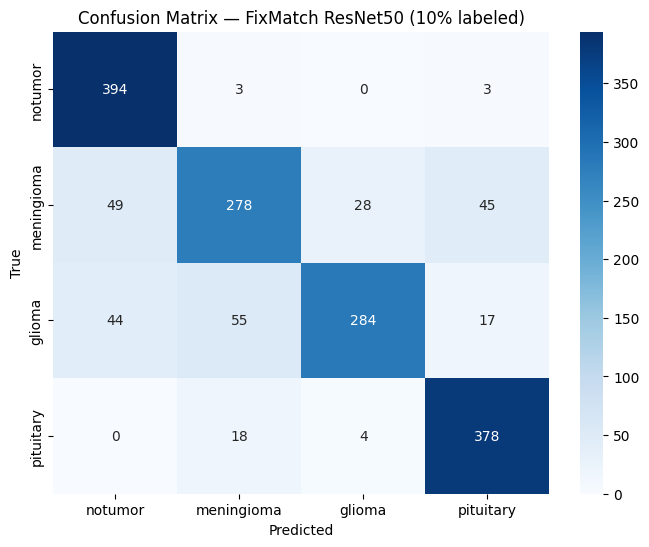

              precision    recall  f1-score   support

     notumor       0.81      0.98      0.89       400
  meningioma       0.79      0.69      0.74       400
      glioma       0.90      0.71      0.79       400
   pituitary       0.85      0.94      0.90       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



In [15]:
# ============================================================
# CELL 6 — Final evaluation
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

model = tf.keras.models.load_model('/content/best_fixmatch.keras')

all_preds, all_true = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — FixMatch ResNet50 (10% labeled)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASSES))

Mean Teacher

In [22]:
# ============================================================
# CELL 1 — Setup + unzip
# ============================================================
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile, glob, os
import matplotlib.pyplot as plt
import seaborn as sns

zip_files = glob.glob('/content/*.zip')
with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall('/content/dataset')

CLASSES      = ['notumor', 'meningioma', 'glioma', 'pituitary']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
DATASET_PATH = '/content/dataset'

print('GPU:', tf.config.list_physical_devices('GPU'))
print('Setup done')

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup done


In [23]:
# ============================================================
# CELL 2 — File paths + 10% labeled split
# ============================================================
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Training',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Testing',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

labeled_idx, unlabeled_idx = train_test_split(
    np.arange(len(train_gen.filepaths)),
    test_size=0.90,   # 10% labeled
    stratify=train_gen.labels,
    random_state=42
)

labeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in labeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in labeled_idx]
})
unlabeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in unlabeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in unlabeled_idx]
})
test_df = pd.DataFrame({
    'filename': test_gen.filepaths,
    'class':    [CLASSES[l] for l in test_gen.labels]
})

print(f' Labeled:   {len(labeled_df)}')
print(f' Unlabeled: {len(unlabeled_df)}')
print(f' Test:      {len(test_df)}')

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Labeled:   560
 Unlabeled: 5040
 Test:      1600


In [24]:
# ============================================================
# CELL 3 — Data pipelines for Mean Teacher
#
# Mean Teacher uses TWO views of the same unlabeled image:
#   - View 1 (weak aug)  → fed to TEACHER to generate soft pseudo-labels
#   - View 2 (weak aug)  → fed to STUDENT, forced to match teacher's output
#
# Unlike FixMatch (weak → teacher, strong → student),
# Mean Teacher uses weak augmentation for BOTH views.
# The teacher's stability (via EMA) handles the noise.
# ============================================================
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = preprocess_input(img)   # ResNet50 preprocessing
    return img

def weak_augment(img):
    """Light augmentation — used for BOTH student and teacher views."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.1)
    return img

def build_labeled_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    img_ds   = tf.data.Dataset.from_tensor_slices(filepaths)
    img_ds   = img_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    img_ds   = img_ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((img_ds, label_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_unlabeled_ds(dataframe, batch_size=32):
    """
    Returns (student_view, teacher_view) pairs.
    Both are weakly augmented — independently sampled augmentations
    of the same image, which is what creates the consistency signal.
    """
    filepaths = dataframe['filename'].values
    raw_ds    = tf.data.Dataset.from_tensor_slices(filepaths)

    # Student view — independently augmented
    student_ds = raw_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    student_ds = student_ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Teacher view — independently augmented (different random seed)
    teacher_ds = raw_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    teacher_ds = teacher_ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = tf.data.Dataset.zip((student_ds, teacher_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_test_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    img_ds   = tf.data.Dataset.from_tensor_slices(filepaths)
    img_ds   = img_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((img_ds, label_ds))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

labeled_ds   = build_labeled_ds(labeled_df)
unlabeled_ds = build_unlabeled_ds(unlabeled_df)
test_ds      = build_test_ds(test_df)

print(' All datasets ready')

 All datasets ready


In [25]:
# ============================================================
# CELL 4 — Build Student and Teacher models
#
# Both share the same architecture.
# Teacher weights are NEVER updated by gradients —
# only via EMA of the student weights after each step.
# ============================================================
def build_resnet_model():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    # Unfreeze last 30 layers
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True

    inputs  = base.input
    x       = layers.GlobalAveragePooling2D()(base.output)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    return Model(inputs, outputs)

student_model = build_resnet_model()
teacher_model = build_resnet_model()

# Copy student weights into teacher at init
teacher_model.set_weights(student_model.get_weights())

# Teacher is NEVER trained directly — disable trainable just for clarity
teacher_model.trainable = False

optimizer = tf.keras.optimizers.Adam(1e-4)

print(' Student and Teacher models ready')
print(f' Trainable params (student): {sum([tf.size(v).numpy() for v in student_model.trainable_variables]):,}')

 Student and Teacher models ready
 Trainable params (student): 14,979,844


In [26]:
# ============================================================
# CELL 5 — EMA update function
#
# After every student gradient step, the teacher is updated as:
#   teacher_weights = alpha * teacher_weights + (1 - alpha) * student_weights
#
# A high alpha (0.99–0.999) means teacher changes slowly,
# giving a smoother, more reliable pseudo-labeler than the student.
#
# The 'ramp-up' trick: start alpha small so teacher adapts quickly
# at first, then increase it for stability. We use a sigmoid ramp.
# ============================================================
EMA_ALPHA = 0.999   # decay for EMA (used after warm-up)

def get_current_alpha(epoch, total_epochs=30, warmup_epochs=5):
    """Sigmoid ramp-up from 0.9 to EMA_ALPHA over warmup_epochs."""
    if epoch < warmup_epochs:
        ramp = epoch / warmup_epochs
        return 0.9 + (EMA_ALPHA - 0.9) * ramp
    return EMA_ALPHA

@tf.function
def update_teacher_ema(alpha):
    """Update teacher weights using EMA of student weights."""
    for t_var, s_var in zip(teacher_model.variables, student_model.variables):
        t_var.assign(alpha * t_var + (1.0 - alpha) * s_var)

print(' EMA update function defined')

 EMA update function defined


In [27]:
# ============================================================
# CELL 6 — Consistency loss with ramp-up weight
#
# Mean Teacher uses a CONSISTENCY LOSS (MSE or KL-divergence)
# between teacher's soft predictions and student's predictions
# on the same (differently augmented) image.
#
# The consistency weight (lambda_u) is RAMPED UP over epochs:
# starting near 0 prevents the untrained teacher from corrupting
# the student early on.
#
# Key difference from FixMatch:
#   - FixMatch uses hard pseudo-labels + confidence threshold
#   - Mean Teacher uses SOFT pseudo-labels from teacher (no threshold needed)
#     → ALL unlabeled samples contribute to the loss
# ============================================================
MAX_LAMBDA_U    = 30.0   # max consistency weight (from original paper)
RAMPUP_EPOCHS   = 10     # epochs to ramp up lambda_u
EPOCHS          = 40

def get_consistency_weight(epoch, rampup=RAMPUP_EPOCHS, max_w=MAX_LAMBDA_U):
    """Sigmoid ramp-up for consistency loss weight."""
    if rampup == 0:
        return max_w
    current = np.clip(epoch / rampup, 0.0, 1.0)
    phase   = 1.0 - current
    return max_w * float(np.exp(-5.0 * phase * phase))

# Supervised cross-entropy loss
supervised_loss_fn = tf.keras.losses.CategoricalCrossentropy()

@tf.function
def consistency_loss(teacher_preds, student_preds):
    """
    MSE between teacher soft predictions and student predictions.
    Teacher preds are treated as soft labels (not one-hot).
    This is the original Mean Teacher formulation from Tarvainen & Valpola 2017.
    """
    return tf.reduce_mean(tf.square(teacher_preds - student_preds))

print(' Consistency loss and weight schedule defined')

 Consistency loss and weight schedule defined


In [28]:
# ============================================================
# CELL 7 — Mean Teacher training step
#
# Each step:
#   1. Student forward pass on labeled data → supervised CE loss
#   2. Teacher forward pass on teacher_view (unlabeled) → soft pseudo-labels
#   3. Student forward pass on student_view (unlabeled) → consistency loss
#   4. Total loss = CE + lambda_u * consistency
#   5. Gradient update on STUDENT only
#   6. EMA update on TEACHER weights
# ============================================================
@tf.function
def train_step(labeled_batch, unlabeled_batch, lambda_u, alpha):
    labeled_imgs, labels  = labeled_batch
    student_imgs, teacher_imgs = unlabeled_batch

    with tf.GradientTape() as tape:
        # ── Supervised loss ──────────────────────────────────
        student_labeled_preds = student_model(labeled_imgs, training=True)
        loss_s = supervised_loss_fn(labels, student_labeled_preds)

        # ── Teacher generates soft pseudo-labels ─────────────
        # Teacher runs in inference mode (no dropout, frozen BN)
        teacher_preds = teacher_model(teacher_imgs, training=False)
        # Stop gradient: teacher is a target, not trained
        teacher_preds = tf.stop_gradient(teacher_preds)

        # ── Student consistency prediction ───────────────────
        student_unlabeled_preds = student_model(student_imgs, training=True)

        # ── Consistency loss (MSE of softmax outputs) ────────
        loss_c = consistency_loss(teacher_preds, student_unlabeled_preds)

        # ── Total loss ───────────────────────────────────────
        total_loss = loss_s + lambda_u * loss_c

    # Update STUDENT via gradients
    grads = tape.gradient(total_loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_model.trainable_variables))

    # Update TEACHER via EMA (outside tape, no gradients)
    update_teacher_ema(alpha)

    return loss_s, loss_c

def evaluate(model, dataset):
    correct, total = 0, 0
    for imgs, labels in dataset:
        preds = model(imgs, training=False)
        correct += tf.reduce_sum(
            tf.cast(tf.equal(tf.argmax(preds, 1), tf.argmax(labels, 1)), tf.float32)
        ).numpy()
        total += len(imgs)
    return correct / total

print(' Training step defined')

 Training step defined


In [29]:
# ============================================================
# CELL 8 — Mean Teacher training loop
#
# We evaluate BOTH student and teacher each epoch.
# Typically the TEACHER outperforms the student because
# it is a temporal ensemble of student checkpoints.
# ============================================================
best_teacher_acc = 0.0
best_student_acc = 0.0

history = {
    'epoch': [], 'loss_s': [], 'loss_c': [],
    'lambda_u': [], 'alpha': [],
    'student_acc': [], 'teacher_acc': []
}

unlabeled_iter = iter(unlabeled_ds.repeat())

print(' Mean Teacher Training')
print(f'  Ramp-up lambda_u: 0 → {MAX_LAMBDA_U} over {RAMPUP_EPOCHS} epochs')
print(f'  EMA alpha: 0.9 → {EMA_ALPHA} (5-epoch warm-up)')
print(f'  Total epochs: {EPOCHS}')
print()
print(f'{"Ep":>4} {"LossS":>7} {"LossC":>7} {"λ_u":>6} {"α":>6} {"StAcc":>7} {"TchAcc":>8}')
print('-' * 57)

for epoch in range(EPOCHS):
    lambda_u = get_consistency_weight(epoch)
    alpha    = get_current_alpha(epoch)
    lambda_u_tf = tf.constant(lambda_u, dtype=tf.float32)
    alpha_tf    = tf.constant(alpha,    dtype=tf.float32)

    s_losses, c_losses = [], []

    for labeled_batch in labeled_ds:
        unlabeled_batch = next(unlabeled_iter)
        ls, lc = train_step(labeled_batch, unlabeled_batch, lambda_u_tf, alpha_tf)
        s_losses.append(ls.numpy())
        c_losses.append(lc.numpy())

    # Evaluate both models
    student_acc = evaluate(student_model, test_ds)
    teacher_acc = evaluate(teacher_model, test_ds)

    # Save best models separately
    if teacher_acc > best_teacher_acc:
        best_teacher_acc = teacher_acc
        teacher_model.save('/content/best_mean_teacher.keras')
    if student_acc > best_student_acc:
        best_student_acc = student_acc
        student_model.save('/content/best_mean_student.keras')

    # Log
    history['epoch'].append(epoch + 1)
    history['loss_s'].append(np.mean(s_losses))
    history['loss_c'].append(np.mean(c_losses))
    history['lambda_u'].append(lambda_u)
    history['alpha'].append(alpha)
    history['student_acc'].append(student_acc)
    history['teacher_acc'].append(teacher_acc)

    print(f'{epoch+1:>4} {np.mean(s_losses):>7.4f} {np.mean(c_losses):>7.4f} '
          f'{lambda_u:>6.1f} {alpha:>6.4f} '
          f'{student_acc*100:>6.2f}% {teacher_acc*100:>7.2f}%')

print(f'\n Best Teacher Accuracy: {best_teacher_acc*100:.2f}%')
print(f' Best Student Accuracy: {best_student_acc*100:.2f}%')

 Mean Teacher Training
  Ramp-up lambda_u: 0 → 30.0 over 10 epochs
  EMA alpha: 0.9 → 0.999 (5-epoch warm-up)
  Total epochs: 40

  Ep   LossS   LossC    λ_u      α   StAcc   TchAcc
---------------------------------------------------------
   1  0.9706  0.0912    0.2 0.9000  70.12%   55.56%
   2  0.2843  0.0573    0.5 0.9198  72.81%   71.06%
   3  0.1854  0.0396    1.2 0.9396  76.31%   75.44%
   4  0.1071  0.0220    2.6 0.9594  76.75%   76.00%
   5  0.0990  0.0283    5.0 0.9792  79.12%   76.75%
   6  0.0796  0.0206    8.6 0.9990  77.00%   76.81%
   7  0.0872  0.0199   13.5 0.9990  79.88%   76.88%
   8  0.1218  0.0246   19.1 0.9990  76.88%   76.88%
   9  0.1123  0.0235   24.6 0.9990  77.19%   77.06%
  10  0.1232  0.0272   28.5 0.9990  79.56%   77.31%
  11  0.1244  0.0234   30.0 0.9990  79.44%   77.56%
  12  0.0992  0.0201   30.0 0.9990  76.69%   77.44%
  13  0.1202  0.0240   30.0 0.9990  78.69%   77.50%
  14  0.0919  0.0200   30.0 0.9990  74.62%   77.44%
  15  0.1236  0.0184   30.0 0.99

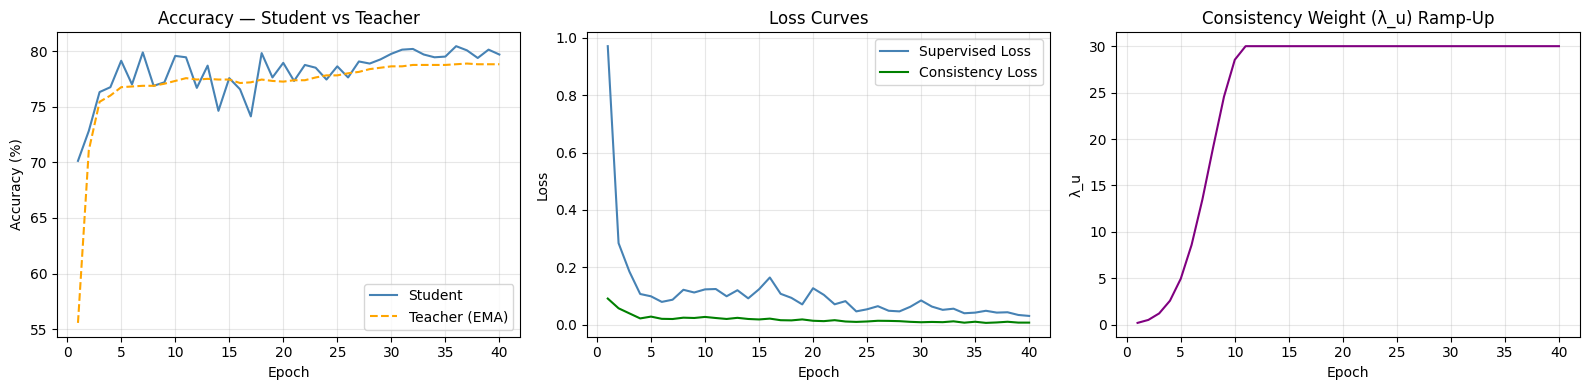

 Curves saved to /content/mean_teacher_curves.png


In [30]:
# ============================================================
# CELL 9 — Training curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy curves
axes[0].plot(history['epoch'], [a*100 for a in history['student_acc']], label='Student', color='steelblue')
axes[0].plot(history['epoch'], [a*100 for a in history['teacher_acc']], label='Teacher (EMA)', color='orange', linestyle='--')
axes[0].set_title('Accuracy — Student vs Teacher')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curves
axes[1].plot(history['epoch'], history['loss_s'], label='Supervised Loss', color='steelblue')
axes[1].plot(history['epoch'], history['loss_c'], label='Consistency Loss', color='green')
axes[1].set_title('Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Lambda ramp-up
axes[2].plot(history['epoch'], history['lambda_u'], color='purple')
axes[2].set_title('Consistency Weight (λ_u) Ramp-Up')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('λ_u')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/mean_teacher_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Curves saved to /content/mean_teacher_curves.png')

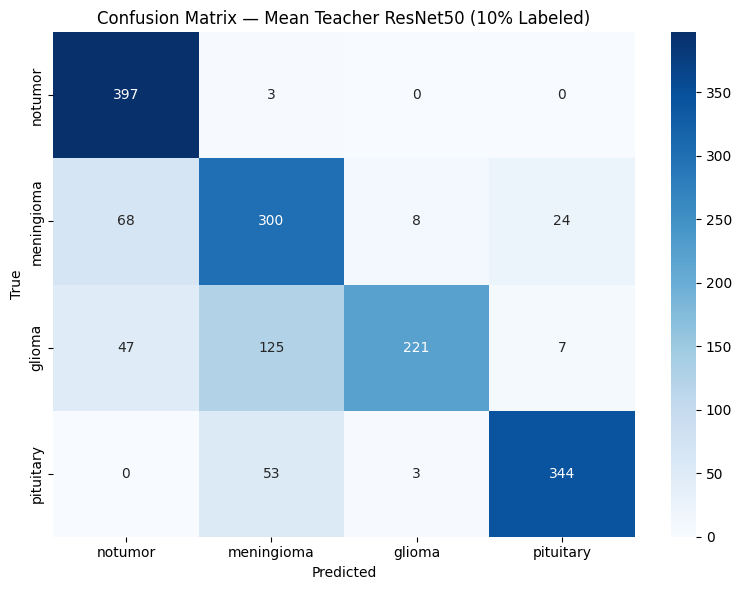

              precision    recall  f1-score   support

     notumor       0.78      0.99      0.87       400
  meningioma       0.62      0.75      0.68       400
      glioma       0.95      0.55      0.70       400
   pituitary       0.92      0.86      0.89       400

    accuracy                           0.79      1600
   macro avg       0.82      0.79      0.78      1600
weighted avg       0.82      0.79      0.78      1600



In [31]:
# ============================================================
# CELL 10 — Final evaluation (Teacher model)
#
# We evaluate the TEACHER — it consistently outperforms
# the student because it is a temporal ensemble.
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

best_teacher = tf.keras.models.load_model('/content/best_mean_teacher.keras')

all_preds, all_true = [], []
for imgs, labels in test_ds:
    preds = best_teacher(imgs, training=False)
    all_preds.extend(np.argmax(preds.numpy(), axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — Mean Teacher ResNet50 (10% Labeled)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/mean_teacher_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASSES))

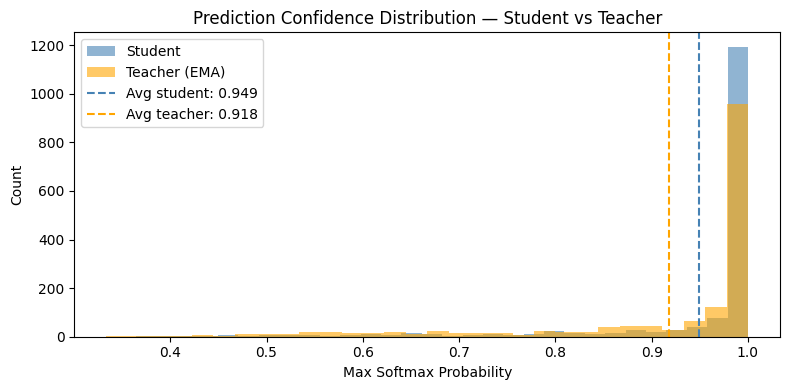

In [32]:
# ============================================================
# CELL 11 — Compare: Student vs Teacher confidence on test set
#
# A well-trained teacher should show:
#   - Higher average confidence
#   - Better calibrated predictions
# ============================================================
best_student = tf.keras.models.load_model('/content/best_mean_student.keras')

student_confidences, teacher_confidences = [], []

for imgs, _ in test_ds:
    s_preds = best_student(imgs, training=False)
    t_preds = best_teacher(imgs, training=False)
    student_confidences.extend(np.max(s_preds.numpy(), axis=1))
    teacher_confidences.extend(np.max(t_preds.numpy(), axis=1))

plt.figure(figsize=(8, 4))
plt.hist(student_confidences, bins=30, alpha=0.6, label='Student', color='steelblue')
plt.hist(teacher_confidences, bins=30, alpha=0.6, label='Teacher (EMA)', color='orange')
plt.axvline(np.mean(student_confidences), color='steelblue', linestyle='--',
            label=f'Avg student: {np.mean(student_confidences):.3f}')
plt.axvline(np.mean(teacher_confidences), color='orange', linestyle='--',
            label=f'Avg teacher: {np.mean(teacher_confidences):.3f}')
plt.title('Prediction Confidence Distribution — Student vs Teacher')
plt.xlabel('Max Softmax Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()